In this notebook, <br/>
1] We employed tabnet on subsets (subcategories; swearwords with subcategories (SW); nonswearwords with subcategories (NSW))
2] We employed CatBoost on subsets (subcategories; swearwords with subcategories (SW); nonswearwords with subcategories (NSW)) <br/>
3] We employed CatBoost + SHAP on subsets (subcategories; swearwords with subcategories (SW); nonswearwords with subcategories (NSW)) <br/>
4] Two functions were created: (a) one for executing the TabNet model and (b) one for visualizing the TabNet chart, allowing all subsets (subcategories, SW, and NSW) to be executed with a single call.  <br/>
5] Two functions were created: (a) one for executing the CatBoost model and (b) one for visualizing the CatBoost chart, allowing all subsets (subcategories, SW, and NSW) to be executed with a single call. <br/>
6] Created function of SHAP, allowing all subsets (subcategories, SW, and NSW) to be executed with a single call. <br/>
7] Computed Spearman rank correlation between tabnet and catboost, SHAP on the above subsets <br/>
8] Computed kendall tau between tabnet and catboost, SHAP on the above subset [Extra] <br/>
9] Used lexicon downloaded from published zenodo

In [1]:
import os
import random
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,f1_score, precision_score, recall_score

/opt/anaconda3/lib/python3.11/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

Reading the Dataset

In [3]:
train_df=pd.read_csv("dataset/hindi_iter2_subcategories_swearwords.csv")
train_df= train_df.dropna()

In [4]:
#------------------------------------ Subcategories------------------------------

X_features_subcat=train_df[["Explicit_Bollywood_Personalities","Explicit_Cricket_Personalities","Explicit_Historical_Figures","Explicit_Media_Personalities","Explicit_Other_Personalities","Explicit_Politician","Explicit_Caste_Groups","Explicit_Political_Groups","Explicit_Religious_Groups","Explicit_Other_Groups","Implicit_Hindus","Implicit_Muslims","Implicit_Others","Implicit_Personalised_Political_Slurs","Implicit_Political_Group_Slurs"]]


#----------------------------Additional Metadata with swear words subcategories ---------------------------------------------
X_features_swear=train_df[['Swear_Explicit_Bollywood_Personalities','Swear_Explicit_Cricket_Personalities','Swear_Explicit_Historical_Figures','Swear_Explicit_Media_Personalities', 'Swear_Explicit_Other_Personalities', 'Swear_Explicit_Politician','Swear_Explicit_Caste_Groups', 'Swear_Explicit_Religious_Groups',
       'Swear_Explicit_Political_Groups', 'Swear_Explicit_Other_Groups',
       'Swear_Implicit_Hindus', 'Swear_Implicit_Muslims',
       'Swear_Implicit_Others', 'Swear_Implicit_Personalised_Political_Slurs',
       'Swear_Implicit_Political_Group_Slurs']]


#----------------------------Additional Metadata with nonswear words subcategories ---------------------------------------------
X_features_nonswear=train_df[['NonSwear_Explicit_Bollywood_Personalities','NonSwear_Explicit_Cricket_Personalities','NonSwear_Explicit_Historical_Figures','NonSwear_Explicit_Media_Personalities', 'NonSwear_Explicit_Other_Personalities', 'NonSwear_Explicit_Politician','NonSwear_Explicit_Caste_Groups', 'NonSwear_Explicit_Religious_Groups',
       'NonSwear_Explicit_Political_Groups', 'NonSwear_Explicit_Other_Groups',
       'NonSwear_Implicit_Hindus', 'NonSwear_Implicit_Muslims',
       'NonSwear_Implicit_Others', 'NonSwear_Implicit_Personalised_Political_Slurs',
       'NonSwear_Implicit_Political_Group_Slurs']]


target=train_df["Mismatch"]

In [5]:
group_map_sub = {
    "Explicit_Caste_Groups": "Explicit Target Groups",
    "Explicit_Other_Groups": "Explicit Target Groups",
    "Explicit_Religious_Groups": "Explicit Target Groups",
    "Explicit_Political_Groups": "Explicit Target Groups",

    "Implicit_Personalised_Political_Slurs": "Implicit Target",
    "Implicit_Hindus": "Implicit Target",
    "Implicit_Political_Group_Slurs": "Implicit Target",
    "Implicit_Others":"Implicit Target",
    "Implicit_Muslims":"Implicit Target",
    
    "Explicit_Cricket_Personalities": "Explicit Target Personalities",
    "Explicit_Media_Personalities": "Explicit Target Personalities",
    "Explicit_Bollywood_Personalities": "Explicit Target Personalities",
    "Explicit_Historical_Figures": "Explicit Target Personalities",
    "Explicit_Other_Personalities": "Explicit Target Personalities",
    "Explicit_Politician": "Explicit Target Personalities"
}

In [6]:
group_map_swear = {
    "Swear_Explicit_Caste_Groups": "Explicit Target Groups",
    "Swear_Explicit_Other_Groups": "Explicit Target Groups",
    "Swear_Explicit_Religious_Groups": "Explicit Target Groups",
    "Swear_Explicit_Political_Groups": "Explicit Target Groups",

    "Swear_Implicit_Personalised_Political_Slurs": "Implicit Target",
    "Swear_Implicit_Hindus": "Implicit Target",
    "Swear_Implicit_Political_Group_Slurs": "Implicit Target",
    "Swear_Implicit_Others":"Implicit Target",
    "Swear_Implicit_Muslims":"Implicit Target",
    
    "Swear_Explicit_Cricket_Personalities": "Explicit Target Personalities",
    "Swear_Explicit_Media_Personalities": "Explicit Target Personalities",
    "Swear_Explicit_Bollywood_Personalities": "Explicit Target Personalities",
    "Swear_Explicit_Historical_Figures": "Explicit Target Personalities",
    "Swear_Explicit_Other_Personalities": "Explicit Target Personalities",
    "Swear_Explicit_Politician": "Explicit Target Personalities"
}


In [7]:
group_map_nonswear = {
    "NonSwear_Explicit_Caste_Groups": "Explicit Target Groups",
    "NonSwear_Explicit_Other_Groups": "Explicit Target Groups",
    "NonSwear_Explicit_Religious_Groups": "Explicit Target Groups",
    "NonSwear_Explicit_Political_Groups": "Explicit Target Groups",

    "NonSwear_Implicit_Personalised_Political_Slurs": "Implicit Target",
    "NonSwear_Implicit_Hindus": "Implicit Target",
    "NonSwear_Implicit_Political_Group_Slurs": "Implicit Target",
    "NonSwear_Implicit_Others":"Implicit Target",
    "NonSwear_Implicit_Muslims":"Implicit Target",
    
    "NonSwear_Explicit_Cricket_Personalities": "Explicit Target Personalities",
    "NonSwear_Explicit_Media_Personalities": "Explicit Target Personalities",
    "NonSwear_Explicit_Bollywood_Personalities": "Explicit Target Personalities",
    "NonSwear_Explicit_Historical_Figures": "Explicit Target Personalities",
    "NonSwear_Explicit_Other_Personalities": "Explicit Target Personalities",
    "NonSwear_Explicit_Politician": "Explicit Target Personalities"
}

**Catboost**

In [8]:
#pip install pytorch-tabnet

In [9]:
# ---- 1) Reproducibility switches ----
#def set_seed(seed: int = 42):
def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Deterministic PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # In case an op doesn't have a deterministic implementation, don't crash.
    torch.use_deterministic_algorithms(True, warn_only=True)

In [10]:
SEED = 42
set_seed(SEED)

**CatBoost**

In [11]:
import catboost as cb
print(cb.__version__)

1.2.7


In [12]:
def train_evaluate_catboost(X_features,target):
    x_train, x_test, y_train, y_test= train_test_split(X_features, target, stratify=target, test_size=0.2, random_state=8)
    cb_model = cb.CatBoostClassifier(iterations=150,learning_rate=0.01,depth=6,loss_function="Logloss",random_seed=43,eval_metric="Accuracy",l2_leaf_reg=3)
    cb_model.fit(x_train, y_train, early_stopping_rounds=200, use_best_model=True)
    y_pred_cb =cb_model.predict(x_test)
    #y_pred_cb = y_pred_cb.astype(int)
    acc= accuracy_score(y_test,y_pred_cb)
    print("ACCURACY OF THE MODEL:",acc )
    f1=f1_score(y_test,y_pred_cb,average='weighted')
    print(f"F1 score:{f1}")

    # Calculate Precision and Recall
    precision = precision_score(y_test, y_pred_cb, average='weighted')
    recall = recall_score(y_test, y_pred_cb, average='weighted')

    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    return cb_model

In [13]:
print("Subcategories")
cat_sub=train_evaluate_catboost(X_features_subcat,target)
print("swear and subcategories")
cat_swear=train_evaluate_catboost(X_features_swear,target)
print("Non Swear and subcategories")
cat_nonswear=train_evaluate_catboost(X_features_nonswear,target)

Subcategories
0:	learn: 0.9195495	total: 56.6ms	remaining: 8.44s
1:	learn: 0.9195495	total: 57.6ms	remaining: 4.26s
2:	learn: 0.9195495	total: 58.2ms	remaining: 2.85s
3:	learn: 0.9195495	total: 59.1ms	remaining: 2.15s
4:	learn: 0.9195495	total: 60ms	remaining: 1.74s
5:	learn: 0.9195495	total: 60.5ms	remaining: 1.45s
6:	learn: 0.9195495	total: 60.9ms	remaining: 1.24s
7:	learn: 0.9195495	total: 61.8ms	remaining: 1.1s
8:	learn: 0.9195495	total: 62.4ms	remaining: 977ms
9:	learn: 0.9195495	total: 62.8ms	remaining: 880ms
10:	learn: 0.9195495	total: 63.7ms	remaining: 805ms
11:	learn: 0.9195495	total: 64.3ms	remaining: 739ms
12:	learn: 0.9195495	total: 65.2ms	remaining: 687ms
13:	learn: 0.9195495	total: 66.8ms	remaining: 649ms
14:	learn: 0.9195495	total: 67.5ms	remaining: 608ms
15:	learn: 0.9195495	total: 68.4ms	remaining: 573ms
16:	learn: 0.9195495	total: 68.7ms	remaining: 537ms
17:	learn: 0.9195495	total: 69.2ms	remaining: 508ms
18:	learn: 0.9195495	total: 69.9ms	remaining: 482ms
19:	learn: 

You should provide test set for use best model. use_best_model parameter has been switched to false value.


121:	learn: 0.9195495	total: 143ms	remaining: 32.9ms
122:	learn: 0.9195495	total: 144ms	remaining: 31.6ms
123:	learn: 0.9195495	total: 145ms	remaining: 30.4ms
124:	learn: 0.9195495	total: 146ms	remaining: 29.1ms
125:	learn: 0.9195495	total: 147ms	remaining: 27.9ms
126:	learn: 0.9195495	total: 147ms	remaining: 26.6ms
127:	learn: 0.9195495	total: 148ms	remaining: 25.4ms
128:	learn: 0.9195495	total: 148ms	remaining: 24.2ms
129:	learn: 0.9195495	total: 149ms	remaining: 22.9ms
130:	learn: 0.9195495	total: 150ms	remaining: 21.7ms
131:	learn: 0.9195495	total: 150ms	remaining: 20.5ms
132:	learn: 0.9195495	total: 151ms	remaining: 19.3ms
133:	learn: 0.9195495	total: 152ms	remaining: 18.1ms
134:	learn: 0.9195495	total: 153ms	remaining: 17ms
135:	learn: 0.9195495	total: 153ms	remaining: 15.8ms
136:	learn: 0.9195495	total: 154ms	remaining: 14.6ms
137:	learn: 0.9195495	total: 155ms	remaining: 13.4ms
138:	learn: 0.9195495	total: 155ms	remaining: 12.3ms
139:	learn: 0.9195495	total: 156ms	remaining: 11

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
You should provide test set for use best model. use_best_model parameter has been switched to false value.
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
You should provide test set for use best model. use_best_model parameter has been switched to false value.


22:	learn: 0.9195495	total: 14.4ms	remaining: 79.3ms
23:	learn: 0.9195495	total: 15.3ms	remaining: 80.5ms
24:	learn: 0.9195495	total: 16ms	remaining: 80.1ms
25:	learn: 0.9195495	total: 16.9ms	remaining: 80.5ms
26:	learn: 0.9195495	total: 17.7ms	remaining: 80.6ms
27:	learn: 0.9195495	total: 18.6ms	remaining: 81.3ms
28:	learn: 0.9195495	total: 19ms	remaining: 79.4ms
29:	learn: 0.9195495	total: 20.6ms	remaining: 82.5ms
30:	learn: 0.9195495	total: 21.2ms	remaining: 81.2ms
31:	learn: 0.9195495	total: 21.6ms	remaining: 79.8ms
32:	learn: 0.9195495	total: 22.2ms	remaining: 78.8ms
33:	learn: 0.9195495	total: 22.6ms	remaining: 77.1ms
34:	learn: 0.9195495	total: 23.5ms	remaining: 77.1ms
35:	learn: 0.9195495	total: 24.4ms	remaining: 77.2ms
36:	learn: 0.9195495	total: 25.3ms	remaining: 77.1ms
37:	learn: 0.9195495	total: 25.6ms	remaining: 75.4ms
38:	learn: 0.9195495	total: 26.1ms	remaining: 74.1ms
39:	learn: 0.9195495	total: 26.7ms	remaining: 73.3ms
40:	learn: 0.9195495	total: 27.1ms	remaining: 72.1

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
def plot_catboost_feature_importance(cat_model,X_features,group_map,title):
    
    # --- 1. Get TabNet feature importances ---
    feature_importances_cat=pd.Series(cat_model.get_feature_importance(),cat_model.feature_names_)

    fi = pd.DataFrame({
        "Feature": feature_importances_cat.index,
        "Importance": feature_importances_cat.values
    }).sort_values(by="Importance", ascending=False)


    fi['group'] = fi['Feature'].map(group_map).fillna('Other')

    # --- 3. Choose a colour per group ---
    colour_map = {
        'Explicit Target Groups': '#e6a37a',        # light peach/orange
        'Implicit Target': '#a7c4d9',               # soft blue
        'Explicit Target Personalities': '#c6e1b5', # soft green
    }

    fi['colour'] = fi['group'].map(colour_map)

    plt.figure(figsize=(15, 10))
    plt.barh(fi["Feature"], fi["Importance"],color=fi['colour'])
    plt.gca().invert_yaxis()
    #plt.xlabel("Importance")
    #plt.ylabel("Features")
    plt.title(title,fontweight='bold',fontsize=22,fontname='Times New Roman',color="black")
    

    # Make tick labels bold
    plt.xticks(fontsize=22,fontname='Times New Roman',color="black",fontweight='bold')
    plt.yticks(fontsize=22,fontname='Times New Roman',color="black",fontweight='bold')

    # --- Create legend manually ---
    legend_handles = [
        Patch(facecolor=color, label=group)
        for group, color in colour_map.items()
    ]

    plt.legend(
        handles=legend_handles,
        title="Feature Categories",
        loc="lower right",
        prop={'weight':'bold','size':18,'family':'Times New Roman'},
        title_fontproperties={'weight':'bold','size':18,'family':'Times New Roman'}
    )
    
    plt.savefig(f"Results/{title}.pdf", bbox_inches="tight")
    plt.tight_layout()
    plt.show()
    return feature_importances_cat

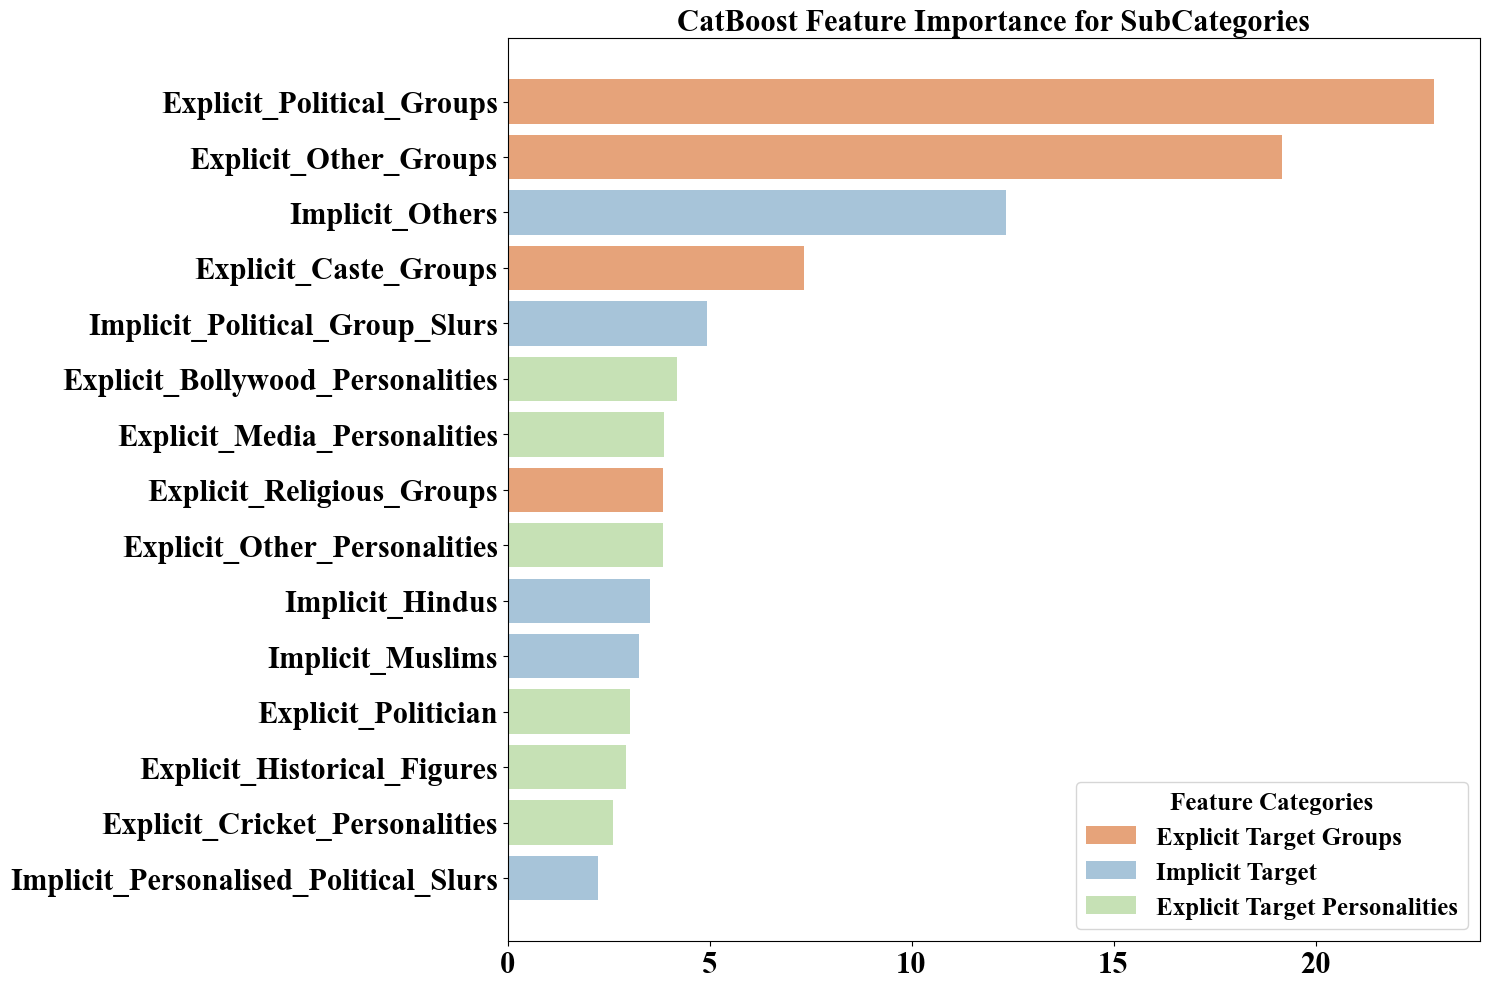

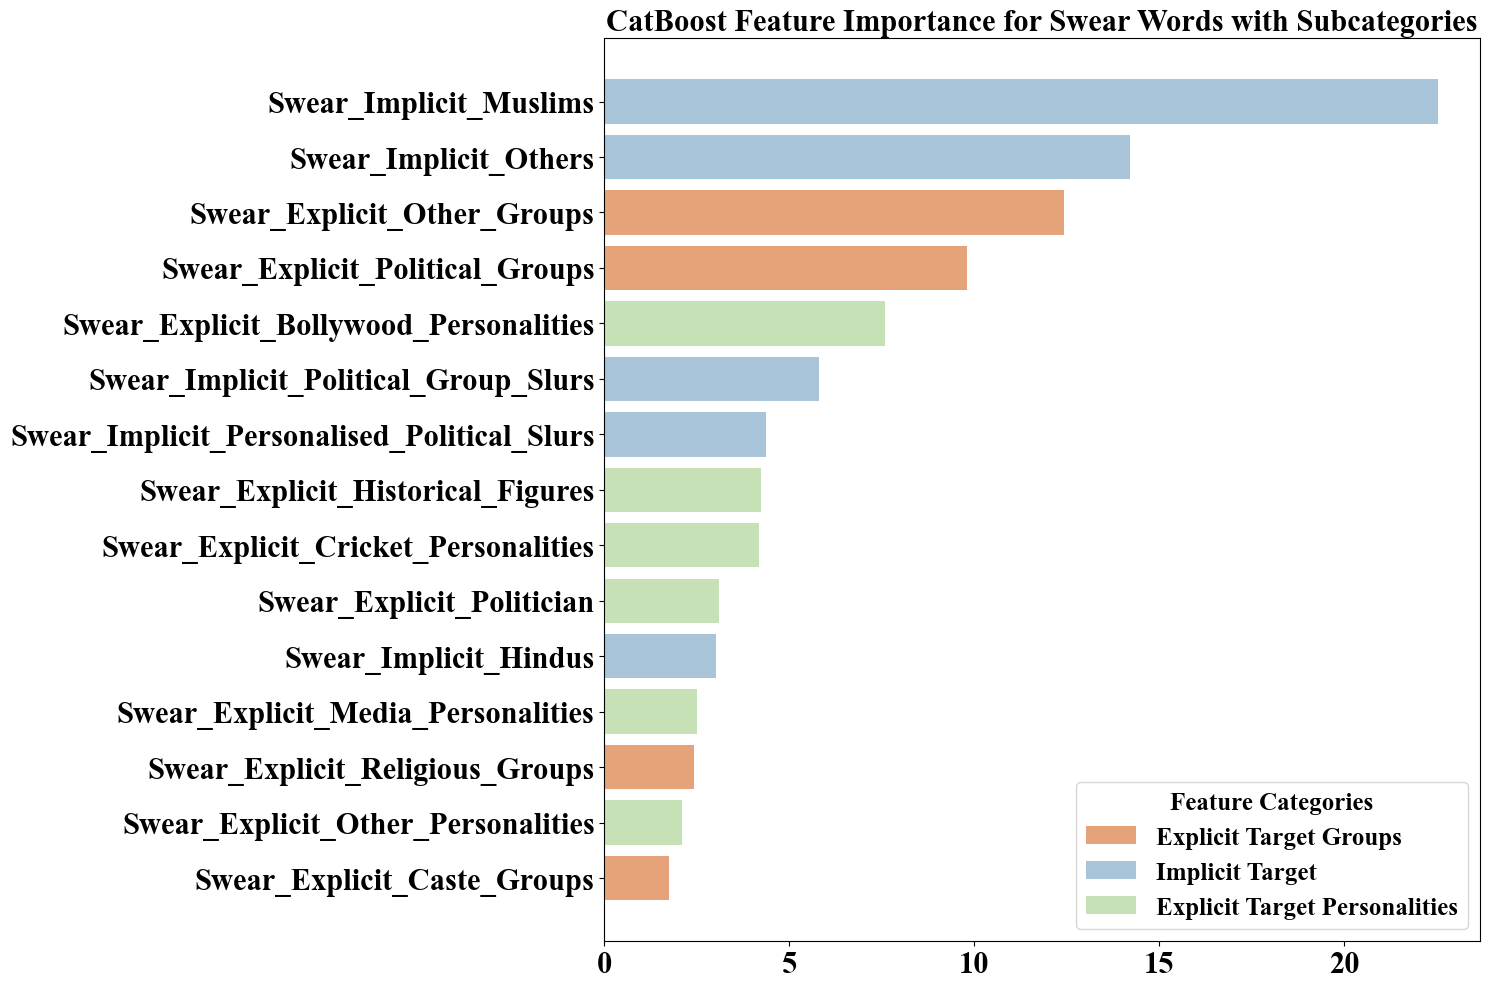

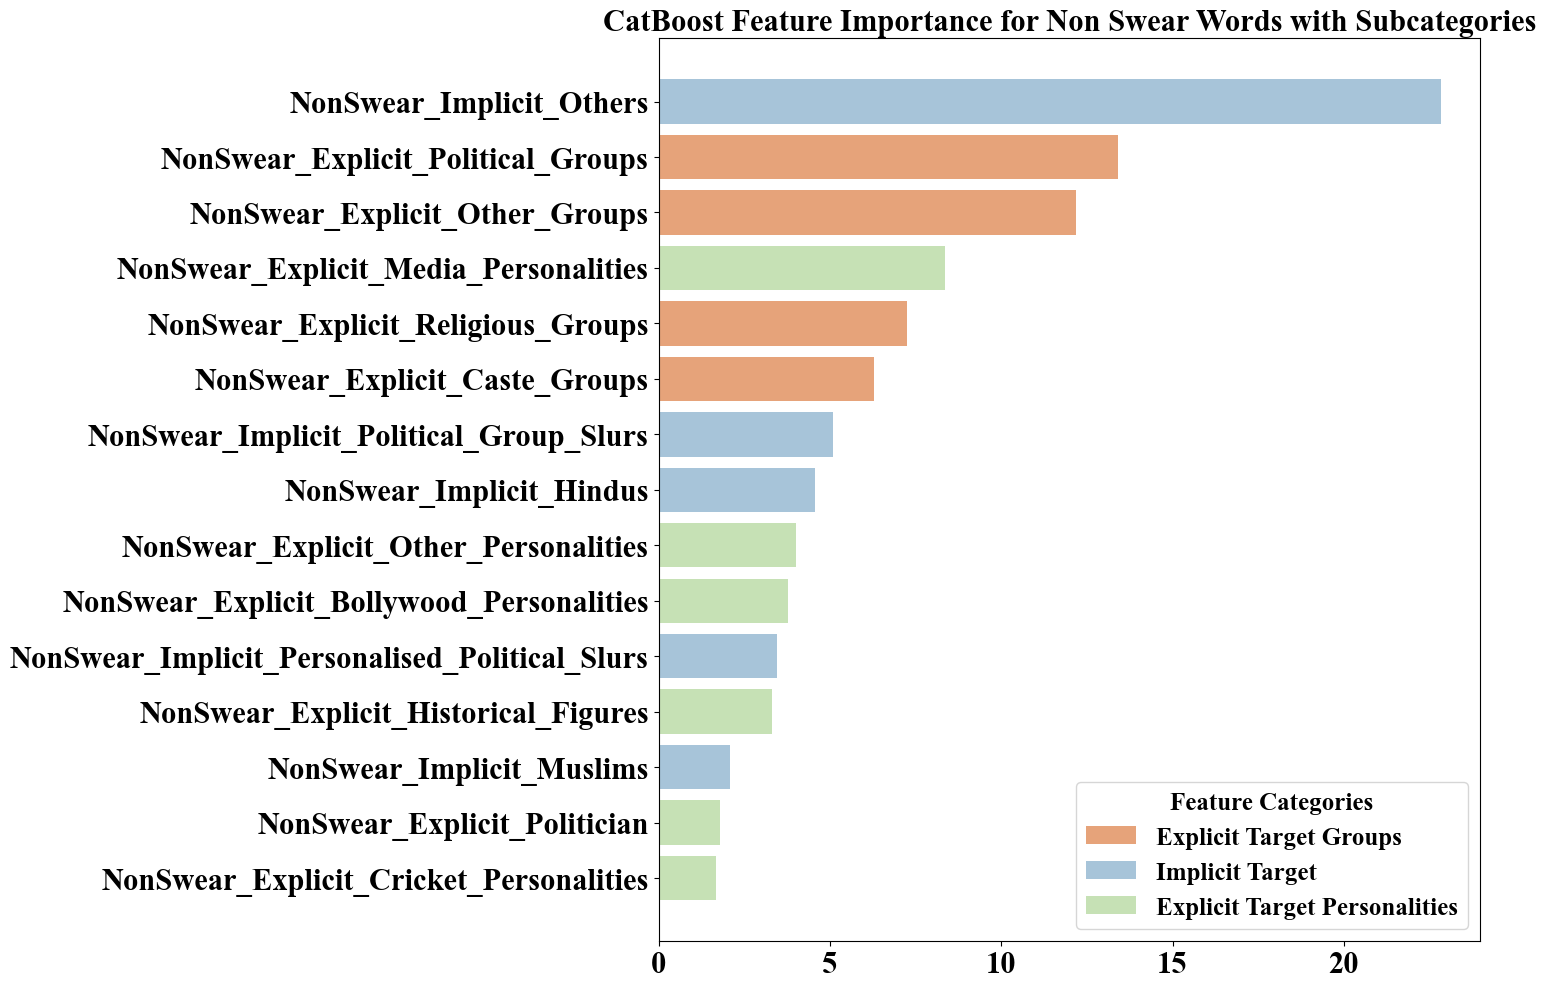

In [15]:
feat_imp_cat_subcat=plot_catboost_feature_importance(cat_sub,X_features_subcat,group_map_sub,"CatBoost Feature Importance for SubCategories")
feat_imp_cat_swear=plot_catboost_feature_importance(cat_swear,X_features_swear,group_map_swear,"CatBoost Feature Importance for Swear Words with Subcategories")
feat_imp_cat_nonswear=plot_catboost_feature_importance(cat_nonswear,X_features_nonswear,group_map_nonswear,"CatBoost Feature Importance for Non Swear Words with Subcategories")

**SHAP for CatBoost**

In [16]:
import shap

In [17]:
def shap_plot(model,X_features,target,title):
    x_train, x_test, y_train, y_test= train_test_split(X_features, target, stratify=target, test_size=0.2, random_state=8)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x_train)
    importances=pd.DataFrame(index=X_features.columns)
    importances['mean_shapley_values'] = np.mean(shap_values, axis=0)
    importances['mean_abs_shapley_values'] = np.mean(np.abs(shap_values),axis=0)
    #shapley = importances.sort_values(by='mean_abs_shapley_values', ascending=False).index
    ## Add to DataFrame
    #shap_features = pd.DataFrame()
    #shap_features['Shapley'] = shapley.values
    # Display
    #shap_features
    shap.summary_plot(shap_values, x_train, plot_type="bar",feature_names=X_features.columns,show=False)
    plt.title(title,fontsize=22, color='black', fontweight='bold',fontname='Times New Roman')
    plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=20, color='black', fontweight='bold')
    plt.xticks(fontsize=22,fontname='Times New Roman',color="black",fontweight='bold')
    plt.yticks(fontsize=22,fontname='Times New Roman',color="black",fontweight='bold')
    plt.savefig(f"Results/{title}.pdf", bbox_inches="tight")
    plt.tight_layout()
    plt.show()
    #return shap_features
    #return shapley.values
    #return shapley
    return importances['mean_abs_shapley_values']


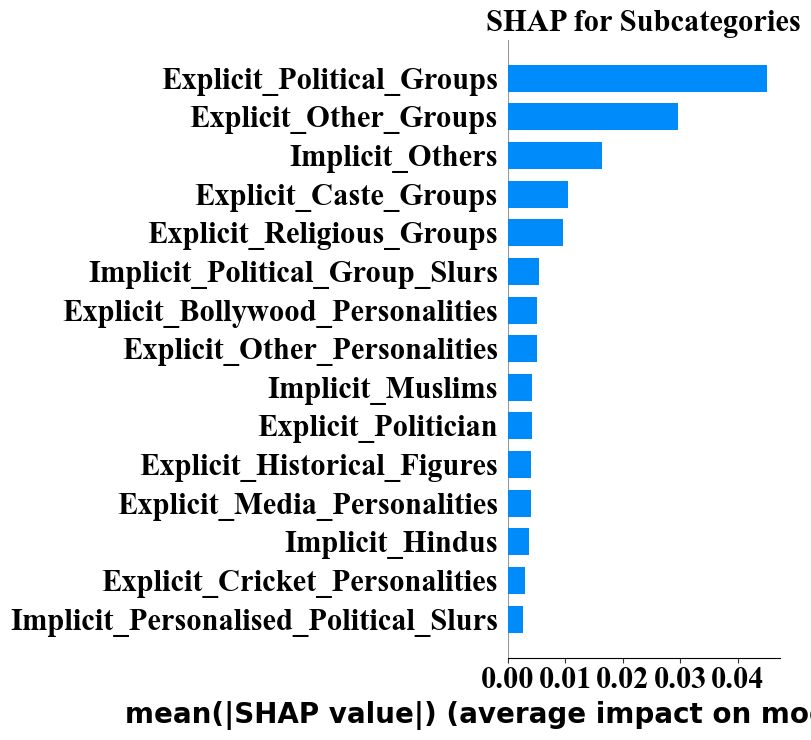

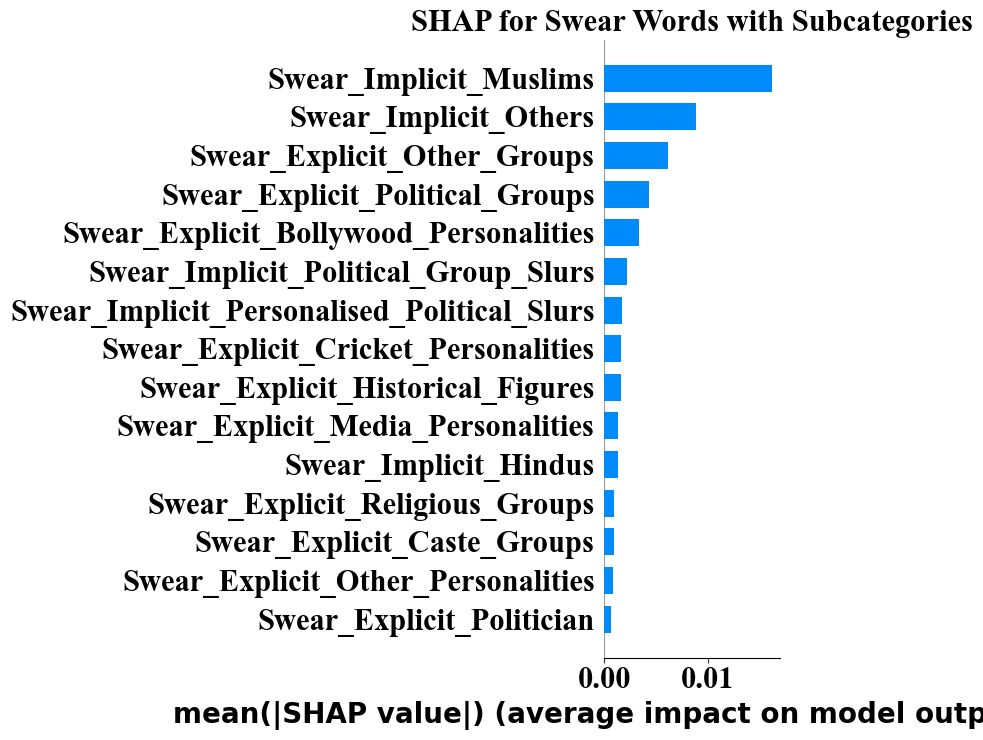

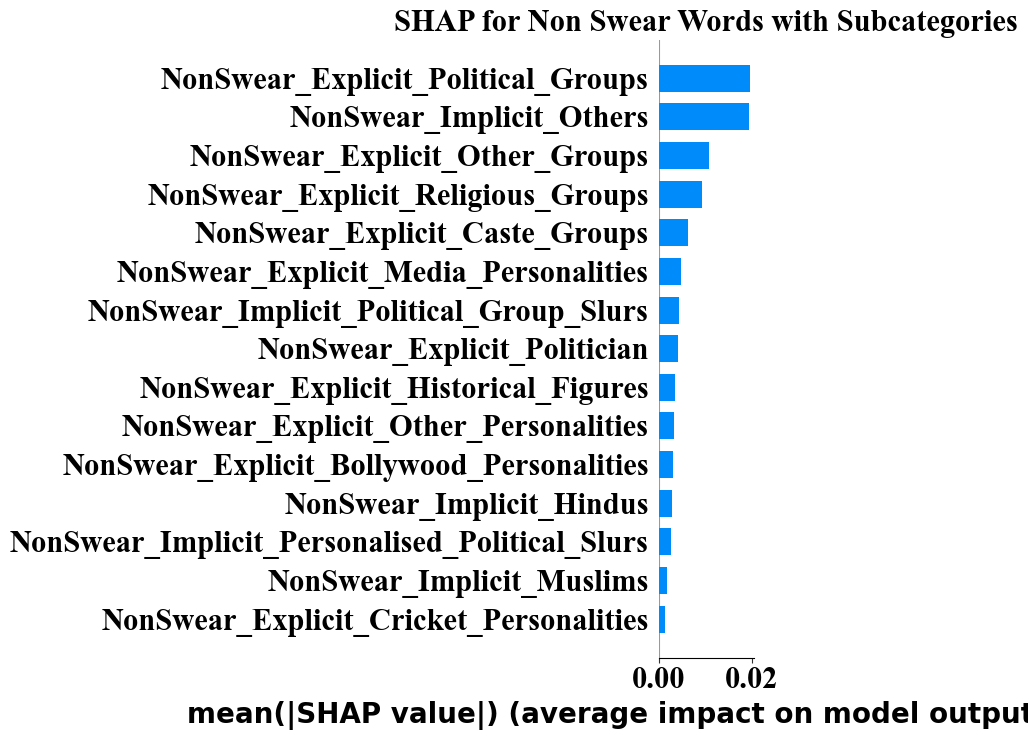

In [18]:
shap_subcat=shap_plot(cat_sub,X_features_subcat,target,"SHAP for Subcategories")
shap_swear=shap_plot(cat_swear,X_features_swear,target,"SHAP for Swear Words with Subcategories")
shap_nonswear=shap_plot(cat_nonswear,X_features_nonswear,target,"SHAP for Non Swear Words with Subcategories")

**TabNET**

In [19]:
import pytorch_tabnet
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score

In [20]:
def train_evaluate_tabnet(X_features,target):
    # ---- 2) Build model with fixed seed & deterministic device ----
    x_train, x_test, y_train, y_test= train_test_split(X_features.values, target, stratify=target, test_size=0.2, random_state=8)
    tab_clf = TabNetClassifier(
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        scheduler_params={"step_size": 10, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        verbose=0,   #not to print epochs clutter
        mask_type="entmax",          # or "sparsemax"
        seed=SEED,                   # TabNet's own internal seed
        device_name="cpu"            # use CPU for strict reproducibility
    )
        # ---- Train ----
    tab_clf.fit(x_train,y_train,eval_set=[(x_test, y_test)])

    # ---- Predict ----
    y_test_pred = tab_clf.predict(x_test)

    # ---- Metrics ----
    test_acc = accuracy_score(y_test, y_test_pred)

    print("ACCURACY OF THE MODEL:", test_acc)
    f1=f1_score(y_test,y_test_pred,average='weighted')
    print(f"F1 score:{f1}")

    # Calculate Precision and Recall
    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')

    print(f'Precision: {precision}')
    print(f'Recall: {recall}')

    return tab_clf

In [21]:
print("Subcategories")
tab_sub=train_evaluate_tabnet(X_features_subcat,target)
print("swear and subcategories")
tab_swear=train_evaluate_tabnet(X_features_swear,target)
print("Non Swear and subcategories")
tab_nonswear=train_evaluate_tabnet(X_features_nonswear,target)

Subcategories

Early stopping occurred at epoch 45 with best_epoch = 35 and best_val_0_auc = 0.62368
ACCURACY OF THE MODEL: 0.9196141479099679
F1 score:0.8811043427211083
Precision: 0.8456901810361762
Recall: 0.9196141479099679
swear and subcategories


/opt/anaconda3/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Early stopping occurred at epoch 10 with best_epoch = 0 and best_val_0_auc = 0.55309
ACCURACY OF THE MODEL: 0.9196141479099679
F1 score:0.8811043427211083
Precision: 0.8456901810361762
Recall: 0.9196141479099679
Non Swear and subcategories


/opt/anaconda3/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Early stopping occurred at epoch 31 with best_epoch = 21 and best_val_0_auc = 0.65201
ACCURACY OF THE MODEL: 0.9196141479099679
F1 score:0.8811043427211083
Precision: 0.8456901810361762
Recall: 0.9196141479099679


/opt/anaconda3/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
def plot_tabnet_feature_importance(tab_model,X_features,group_map,title):
    
    # --- 1. Get TabNet feature importances ---
    feature_importances_tab = pd.Series(tab_model.feature_importances_, index=X_features.columns)


    # Attach group labels
    feat_df = pd.DataFrame({
        'feature': feature_importances_tab.index,
        'importance': feature_importances_tab.values
    })
    feat_df['group'] = feat_df['feature'].map(group_map).fillna('Other')

    # --- 3. Choose a colour per group ---
    colour_map = {
        'Explicit Target Groups': '#e6a37a',        # light peach/orange
        'Implicit Target': '#a7c4d9',               # soft blue
        'Explicit Target Personalities': '#c6e1b5', # soft green
    }

    feat_df['colour'] = feat_df['group'].map(colour_map)

    # --- 4. Sort (ascending or descending) ---
    feat_df = feat_df.sort_values('importance', ascending=True)



    # --- 5. Plot ---
    plt.figure(figsize=(15, 10))
    plt.barh(feat_df['feature'], feat_df['importance'], color=feat_df['colour'])
    #plt.xlabel("Feature Importance")
    #plt.ylabel("Features")
    plt.title(title,fontweight='bold',fontsize=22,fontname='Times New Roman',color="black")
    #plt.title(title,fontsize=20)
    # Make tick labels bold


    plt.xticks(fontsize=22,fontname='Times New Roman',color="black",fontweight='bold')
    plt.yticks(fontsize=22,fontname='Times New Roman',color="black",fontweight='bold')
    # --- Create legend manually ---
    legend_handles = [
        Patch(facecolor=color, label=group)
        for group, color in colour_map.items()
    ]

    plt.legend(
        handles=legend_handles,
        title="Feature Categories",
        loc="lower right",
        prop={'weight':'bold','size':18,'family':'Times New Roman'},
        title_fontproperties={'weight':'bold','size':18,'family':'Times New Roman'}
    )
    plt.savefig(f"Results/{title}.pdf", bbox_inches="tight")
    plt.tight_layout()
    plt.show()
    return feature_importances_tab 

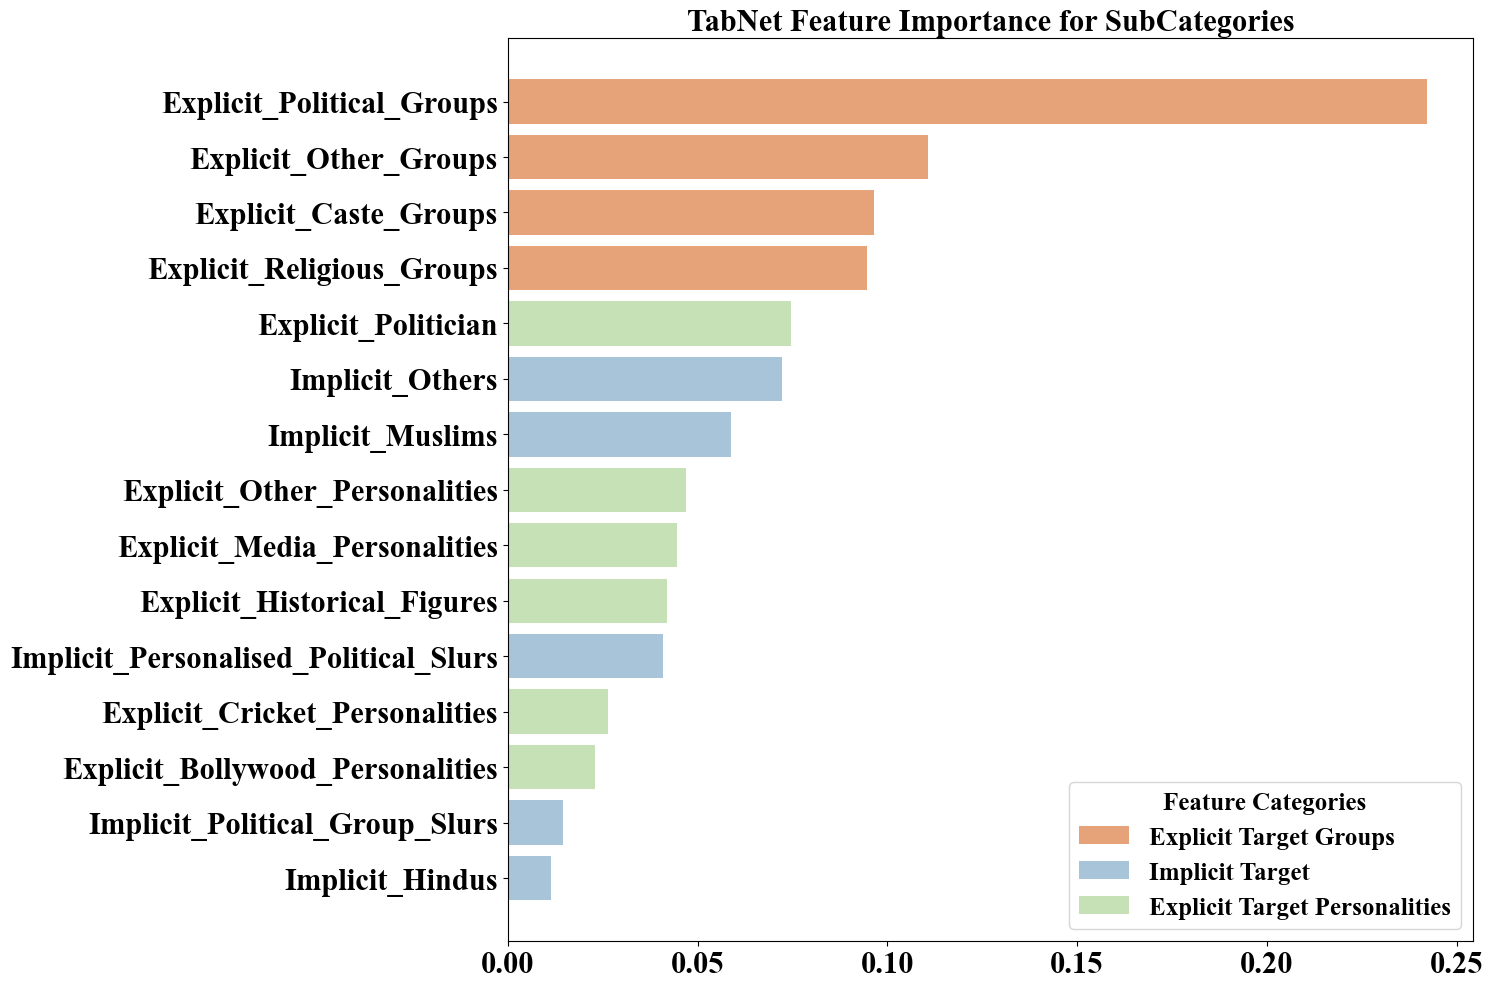

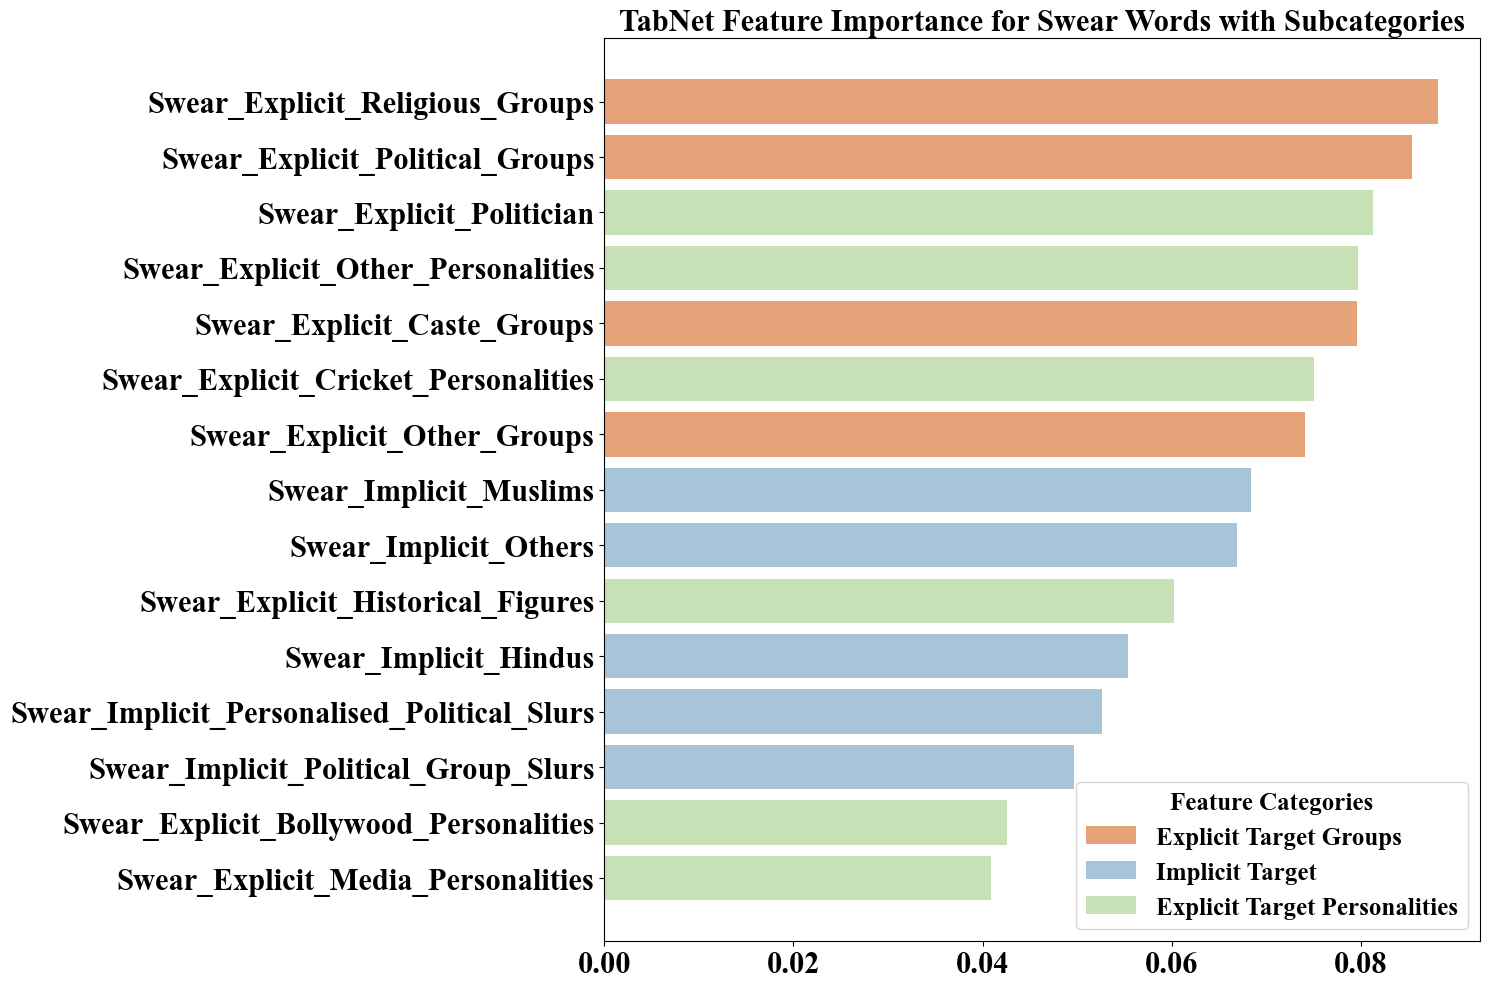

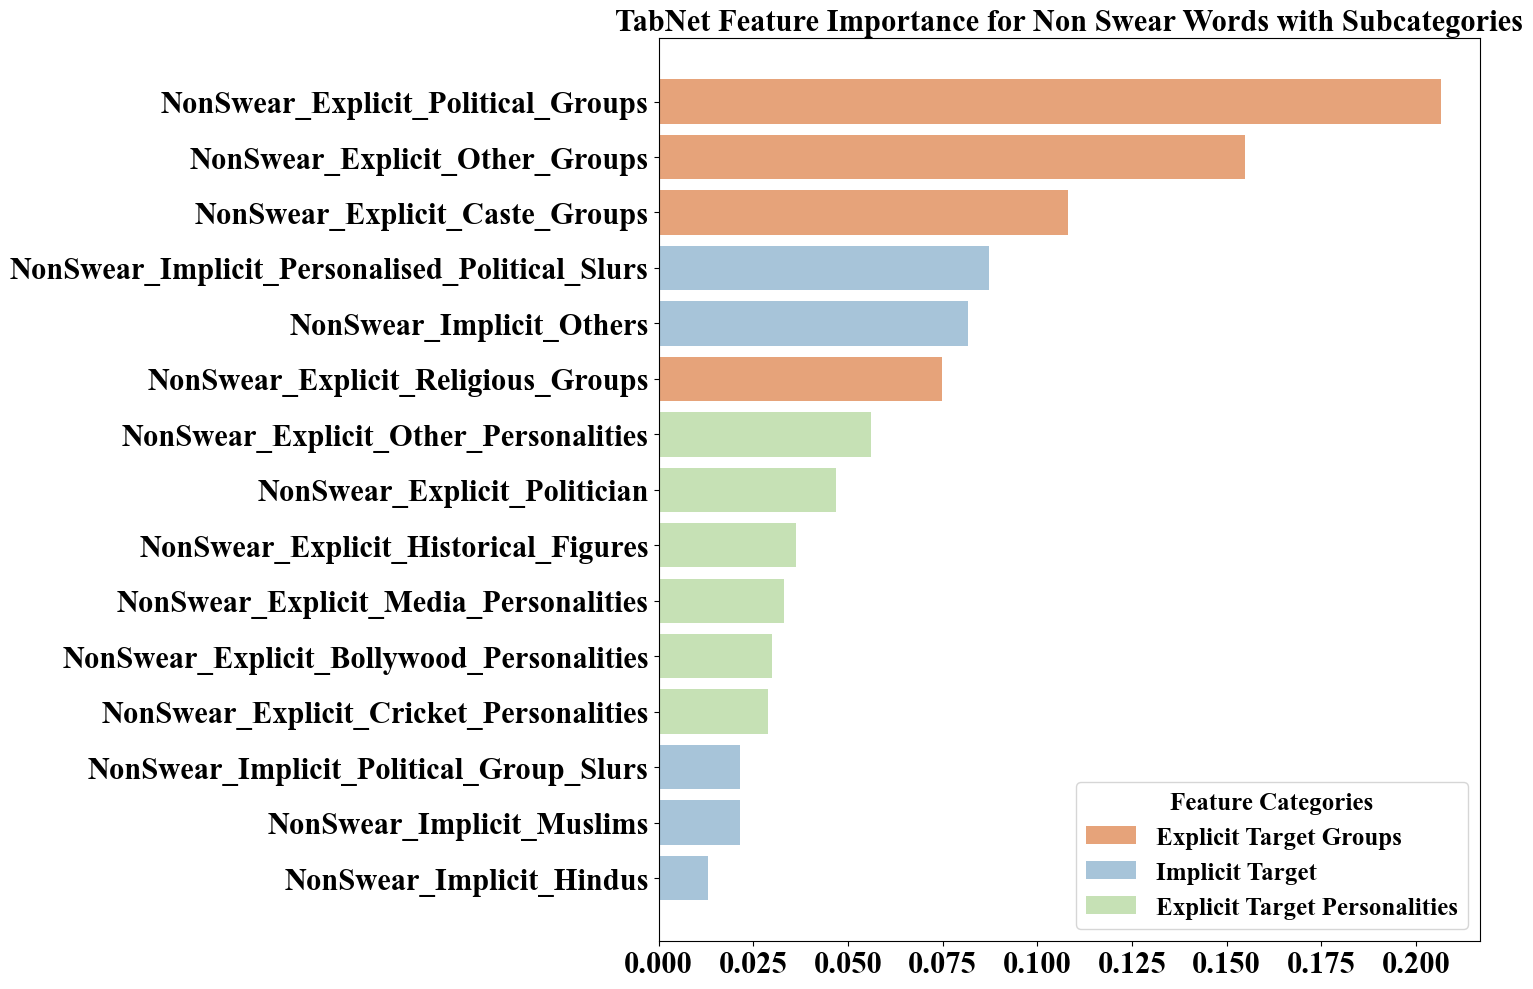

In [23]:
feat_imp_tab_subcat=plot_tabnet_feature_importance(tab_sub,X_features_subcat,group_map_sub,"TabNet Feature Importance for SubCategories")
feat_imp_tab_swear=plot_tabnet_feature_importance(tab_swear,X_features_swear,group_map_swear,"TabNet Feature Importance for Swear Words with Subcategories")
feat_imp_tab_nonswear=plot_tabnet_feature_importance(tab_nonswear,X_features_nonswear,group_map_nonswear,"TabNet Feature Importance for Non Swear Words with Subcategories")

**Spearman Rank Correlation**

In [24]:
from scipy.stats import spearmanr

In [25]:
feat_imp_cat_swear

Swear_Explicit_Bollywood_Personalities          7.590208
Swear_Explicit_Cricket_Personalities            4.168265
Swear_Explicit_Historical_Figures               4.224335
Swear_Explicit_Media_Personalities              2.500949
Swear_Explicit_Other_Personalities              2.093309
Swear_Explicit_Politician                       3.108415
Swear_Explicit_Caste_Groups                     1.744295
Swear_Explicit_Religious_Groups                 2.415117
Swear_Explicit_Political_Groups                 9.812055
Swear_Explicit_Other_Groups                    12.436991
Swear_Implicit_Hindus                           3.012686
Swear_Implicit_Muslims                         22.540338
Swear_Implicit_Others                          14.197721
Swear_Implicit_Personalised_Political_Slurs     4.357317
Swear_Implicit_Political_Group_Slurs            5.797998
dtype: float64

In [26]:
feat_imp_tab_swear

Swear_Explicit_Bollywood_Personalities         0.042578
Swear_Explicit_Cricket_Personalities           0.075034
Swear_Explicit_Historical_Figures              0.060218
Swear_Explicit_Media_Personalities             0.040890
Swear_Explicit_Other_Personalities             0.079658
Swear_Explicit_Politician                      0.081298
Swear_Explicit_Caste_Groups                    0.079573
Swear_Explicit_Religious_Groups                0.088204
Swear_Explicit_Political_Groups                0.085447
Swear_Explicit_Other_Groups                    0.074104
Swear_Implicit_Hindus                          0.055401
Swear_Implicit_Muslims                         0.068377
Swear_Implicit_Others                          0.066915
Swear_Implicit_Personalised_Political_Slurs    0.052615
Swear_Implicit_Political_Group_Slurs           0.049686
dtype: float64

In [27]:
shap_swear

Swear_Explicit_Bollywood_Personalities         0.003328
Swear_Explicit_Cricket_Personalities           0.001631
Swear_Explicit_Historical_Figures              0.001583
Swear_Explicit_Media_Personalities             0.001318
Swear_Explicit_Other_Personalities             0.000821
Swear_Explicit_Politician                      0.000662
Swear_Explicit_Caste_Groups                    0.000914
Swear_Explicit_Religious_Groups                0.000933
Swear_Explicit_Political_Groups                0.004309
Swear_Explicit_Other_Groups                    0.006191
Swear_Implicit_Hindus                          0.001277
Swear_Implicit_Muslims                         0.016165
Swear_Implicit_Others                          0.008846
Swear_Implicit_Personalised_Political_Slurs    0.001715
Swear_Implicit_Political_Group_Slurs           0.002204
Name: mean_abs_shapley_values, dtype: float64

In [28]:
correl_catshap_subcat,p_catshap_subcat=spearmanr(feat_imp_cat_subcat,shap_subcat)
correl_catshap_swear,p_catshap_swear=spearmanr(feat_imp_cat_swear,shap_swear)
correl_catshap_nonswear,p_catshap_nonswear=spearmanr(feat_imp_cat_nonswear,shap_nonswear)

In [29]:
correl_tabcat_subcat,p_tabcat_subcat=spearmanr(feat_imp_tab_subcat,feat_imp_cat_subcat)
correl_tabcat_swear,p_tabcat_swear=spearmanr(feat_imp_tab_swear,feat_imp_cat_swear)
correl_tabcat_nonswear,p_tabcat_nonswear=spearmanr(feat_imp_tab_nonswear,feat_imp_cat_nonswear)

In [30]:
correl_tabshap_subcat,p_tabshap_subcat=spearmanr(feat_imp_tab_subcat,shap_subcat)
correl_tabshap_swear,p_tabshap_swear=spearmanr(feat_imp_tab_swear,shap_swear)
correl_tabshap_nonswear,p_tabshap_nonswear=spearmanr(feat_imp_tab_nonswear,shap_nonswear)

In [31]:
import pandas as pd

df_all = pd.DataFrame({
    "Comparison": (
        ["CatBoost vs SHAP"] * 3 +
        ["TabNet vs CatBoost"] * 3 +
        ["TabNet vs SHAP"] * 3
    ),
    "Category": ["Subcategories", "Swear Words", "Non-Swear Words"] * 3,
    "Spearman Correlation": [
        correl_catshap_subcat, correl_catshap_swear, correl_catshap_nonswear,
        correl_tabcat_subcat, correl_tabcat_swear, correl_tabcat_nonswear,
        correl_tabshap_subcat, correl_tabshap_swear, correl_tabshap_nonswear
    ],
    "p-value": [
        p_catshap_subcat, p_catshap_swear, p_catshap_nonswear,
        p_tabcat_subcat, p_tabcat_swear, p_tabcat_nonswear,
        p_tabshap_subcat, p_tabshap_swear, p_tabshap_nonswear
    ]
})

pd.options.display.float_format = '{:.6f}'.format
df_all

,Comparison,Category,Spearman Correlation,p-value
0,CatBoost vs SHAP,Subcategories,0.896429,0.000006
1,CatBoost vs SHAP,Swear Words,0.935714,0.000000
2,CatBoost vs SHAP,Non-Swear Words,0.864286,0.000032
3,TabNet vs CatBoost,Subcategories,0.500000,0.057699
4,TabNet vs CatBoost,Swear Words,-0.228571,0.412566
5,TabNet vs CatBoost,Non-Swear Words,0.539286,0.038022
6,TabNet vs SHAP,Subcategories,0.689286,0.004474
7,TabNet vs SHAP,Swear Words,-0.307143,0.265473
8,TabNet vs SHAP,Non-Swear Words,0.682143,0.005086


**Extra Analysis**
kendall tau for extra analysis

**Kendall tau**

In [32]:
from scipy.stats import kendalltau

In [33]:
kendall_catshap_subcat,kp_catshap_subcat=kendalltau(feat_imp_cat_subcat,shap_subcat)
kendall_catshap_swear,kp_catshap_swear=kendalltau(feat_imp_cat_swear,shap_swear)
kendall_catshap_nonswear,kp_catshap_nonswear=kendalltau(feat_imp_cat_nonswear,shap_nonswear)

In [34]:
kendall_tabcat_subcat,kp_tabcat_subcat=kendalltau(feat_imp_tab_subcat,feat_imp_cat_subcat)
kendall_tabcat_swear,kp_tabcat_swear=kendalltau(feat_imp_tab_swear,feat_imp_cat_swear)
kendall_tabcat_nonswear,kp_tabcat_nonswear=kendalltau(feat_imp_tab_nonswear,feat_imp_cat_nonswear)

In [35]:
kendall_tabshap_subcat,kp_tabshap_subcat=kendalltau(feat_imp_tab_subcat,shap_subcat)
kendall_tabshap_swear,kp_tabshap_swear=kendalltau(feat_imp_tab_swear,shap_swear)
kendall_tabshap_nonswear,kp_tabshap_nonswear=kendalltau(feat_imp_tab_nonswear,shap_nonswear)

In [36]:
import pandas as pd

df_all = pd.DataFrame({
    "Comparison": (
        ["CatBoost vs SHAP"] * 3 +
        ["TabNet vs CatBoost"] * 3 +
        ["TabNet vs SHAP"] * 3
    ),
    "Category": ["Subcategories", "Swear Words", "Non-Swear Words"] * 3,
    "kendalltau": [
        kendall_catshap_subcat, kendall_catshap_swear, kendall_catshap_nonswear,
        kendall_tabcat_subcat, kendall_tabcat_swear, kendall_tabcat_nonswear,
        kendall_tabshap_subcat, kendall_tabshap_swear, kendall_tabshap_nonswear
    ],
    "p-value": [
        kp_catshap_subcat, kp_catshap_swear, kp_catshap_nonswear,
        kp_tabcat_subcat, kp_tabcat_swear, kp_tabcat_nonswear,
       kp_tabshap_subcat, kp_tabshap_swear, kp_tabshap_nonswear
    ]
})

#pd.options.display.float_format = '{:.4f}'.format
pd.options.display.float_format = '{:.6f}'.format
df_all

,Comparison,Category,kendalltau,p-value
0,CatBoost vs SHAP,Subcategories,0.809524,0.000002
1,CatBoost vs SHAP,Swear Words,0.847619,0.000000
2,CatBoost vs SHAP,Non-Swear Words,0.714286,0.000067
3,TabNet vs CatBoost,Subcategories,0.371429,0.058996
4,TabNet vs CatBoost,Swear Words,-0.161905,0.435119
5,TabNet vs CatBoost,Non-Swear Words,0.390476,0.046292
6,TabNet vs SHAP,Subcategories,0.523810,0.005902
7,TabNet vs SHAP,Swear Words,-0.238095,0.239459
8,TabNet vs SHAP,Non-Swear Words,0.523810,0.005902


Kendall tau is for extra analysis

In [37]:
print("Done")

Done
